# HQT — 검증 노트북 (전처리부터 통합)

본 노트북은 학위논문/심사 검증용 자기완결형 실행 흐름이다. **DL 재학습은 안 하고** 저장된 `.pth` 로 baseline 만 산출한다. 단 전처리 (HP-filter trend + Fourier 분해) 는 재현 가능하므로 매 실행마다 다시 계산한다.

**전체 흐름**
1. 데이터 로드
2. HP-filter 추세 추출
3. Fourier 계절성 분해 (K 그리드서치)
4. Train / Val / Test 분할
5. 저장된 `.pth` 로 baseline (hybrid) 산출 — **DL 재학습 X**
6. H0 점예측 평가
7. HQT 모델 정의 (γ_h 포함)
8. PyMC NUTS 사후 추론
9. γ_h posterior 표
10. H0/H1/H2 점예측 비교 (Full + Event)
11. 90% PI Calibration
12. 2024 명절 시각화
13. 최종 요약

**의존 산출물** (작업 디렉토리 = `src/`)
- `best_model_20260518_011512.pth`, `best_params.json`
- `scaler_X.joblib`, `scaler_y.joblib`
- `power_demand_final.csv` (원본 경로)

## 0. Setup

In [1]:
import sys, pathlib, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.filters.hp_filter import hpfilter
from itertools import product

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

_PROJ_ROOT = pathlib.Path("..").resolve()
if str(_PROJ_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJ_ROOT))

DATA_PATH = "/Users/ijongseung/Demadn-Quadratic-Tilting/power_demand_final.csv"
CKPT_PATH = "best_model_20260518_011512.pth"

print(f"project root : {_PROJ_ROOT}")
print(f"data         : {DATA_PATH}")
print(f"checkpoint   : {CKPT_PATH}")


project root : /Users/ijongseung/Documents/GitHub/arima-type/Demadn-Quadratic-Tilting
data         : /Users/ijongseung/Demadn-Quadratic-Tilting/power_demand_final.csv
checkpoint   : best_model_20260518_011512.pth


## 1. 데이터 로드

In [2]:
df = pd.read_csv(DATA_PATH)
df["일시"] = pd.to_datetime(df["일시"])
df["holiday_name"] = df["holiday_name"].fillna("non-event")
df = df.sort_values("일시").reset_index(drop=True)

print(f"총 {len(df):,} 행 / 컬럼 {len(df.columns)}개")
print(f"기간: {df['일시'].min()} ~ {df['일시'].max()}")
print(f"컬럼: {list(df.columns)}")


총 51,144 행 / 컬럼 12개
기간: 2019-01-01 00:00:00 ~ 2024-10-31 23:00:00
컬럼: ['일시', 'hm', 'ta', 'power demand(MW)', 'holiday_name', 'weekday', 'weekend', 'spring', 'summer', 'autoum', 'winter', 'is_holiday_dummies']


## 2. HP-filter 추세 추출

전체 데이터(train+val+test) 에 HP-filter 를 적용해 양방향 필터의 endpoint 왜곡을 제거. 추세는 예측 대상이 아닌 구조적 분해 성분이므로 leakage 아님.

$\lambda = 1.28\times10^{8}$ (Ravn–Uhlig 2002 기준의 실용 범위)

In [3]:
LAMBDA_HP = 1.28e8

y_all_raw = df["power demand(MW)"].values
_, trend_all = hpfilter(y_all_raw, lamb=LAMBDA_HP)

df["trend"]   = trend_all
df["detrend"] = df["power demand(MW)"] - df["trend"]

print(f"trend range : {trend_all.min():,.1f} ~ {trend_all.max():,.1f} MW")
print(f"detrend std : {df['detrend'].std():,.1f} MW")


trend range : 52,759.9 ~ 76,530.4 MW
detrend std : 7,601.7 MW


/Users/ijongseung/Documents/GitHub/arima-type/Demadn-Quadratic-Tilting/.venv/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


## 3. Fourier 계절성 분해 (K 그리드서치)

일·주·연 주기 각각의 K (조화 차수) 를 train/val MSE 로 그리드서치. 결정론적이라 매 실행마다 동일 K 가 선택됨.

In [4]:
def generate_fourier_terms(timesteps, period, K):
    terms = []
    for k in range(1, K + 1):
        terms.append(np.sin(2 * np.pi * k * timesteps / period))
        terms.append(np.cos(2 * np.pi * k * timesteps / period))
    return np.stack(terms, axis=1)

y_all = df["detrend"].values
t_all = np.arange(len(y_all))

train_end = int((df["일시"] <= "2022-12-31 23:00:00").sum())
val_end   = int((df["일시"] <= "2023-12-31 23:00:00").sum())

best_mse = float("inf")
best_model, best_X_all, best_K_combo = None, None, None

for Kd, Kw, Ky in product([1,2,3], [1,2,3,4,5,6,7,8], [1,2,3,4]):
    X_all = np.hstack([
        generate_fourier_terms(t_all, 24, Kd),
        generate_fourier_terms(t_all, 24*7, Kw),
        generate_fourier_terms(t_all, 24*365.25, Ky),
    ])
    X_tr, X_va = X_all[:train_end], X_all[train_end:val_end]
    y_tr, y_va = y_all[:train_end], y_all[train_end:val_end]

    m = LinearRegression().fit(X_tr, y_tr)
    mse = mean_squared_error(y_va, m.predict(X_va))
    if mse < best_mse:
        best_mse, best_model, best_X_all, best_K_combo = mse, m, X_all, (Kd, Kw, Ky)

seasonality_pred = best_model.predict(best_X_all)
residuals = y_all - seasonality_pred

df["Fourier_Seasonality"] = seasonality_pred
df["Fourier_Residual"]    = residuals
df["t"] = t_all

print(f"best K (daily, weekly, yearly) = {best_K_combo}")
print(f"best val MSE = {best_mse:,.2f}")
print(f"Fourier_Residual std = {df['Fourier_Residual'].std():,.1f} MW")


best K (daily, weekly, yearly) = (3, 8, 1)
best val MSE = 16,535,087.95
Fourier_Residual std = 3,925.2 MW


## 4. Train / Val / Test 분할

In [5]:
train = df[df["일시"] <= "2022-12-31 23:00:00"].copy()
val   = df[(df["일시"] > "2022-12-31 23:00:00") & (df["일시"] <= "2023-12-31 23:00:00")].copy()
test  = df[df["일시"] >  "2023-12-31 23:00:00"].copy()

# 인덱스를 datetime 으로 (HQT pipeline 에서 _date_index 가 인덱스 사용)
for d_ in (train, val, test):
    d_.set_index("일시", inplace=True)
    d_.sort_index(inplace=True)

print(f"train : {len(train):>6,} h   ({train.index.min().date()} ~ {train.index.max().date()})")
print(f"val   : {len(val):>6,} h   ({val.index.min().date()} ~ {val.index.max().date()})")
print(f"test  : {len(test):>6,} h   ({test.index.min().date()} ~ {test.index.max().date()})")


train : 35,064 h   (2019-01-01 ~ 2022-12-31)
val   :  8,760 h   (2023-01-01 ~ 2023-12-31)
test  :  7,320 h   (2024-01-01 ~ 2024-10-31)


## 5. Baseline 추론 (저장된 `.pth`)

`infer_baseline()` 한 줄로 학습 산출물에서 train/val/test 의 hybrid baseline 만 산출. DL 재학습 안 함.

In [6]:
from demand_quadratic_tilting.inference import infer_baseline

feature_cols = ["hm", "ta", "Fourier_Residual",
                "spring", "summer", "autoum", "winter", "is_holiday_dummies"]
target_col = "Fourier_Residual"

train_pred_inv, val_pred_inv, test_pred_inv = infer_baseline(
    train_df=train, val_df=val, test_df=test,
    ckpt_path=CKPT_PATH,
    best_params_path="best_params.json",
    scaler_X_path="scaler_X.joblib",
    scaler_y_path="scaler_y.joblib",
    feature_cols=feature_cols,
    target_col=target_col,
    in_days=7, out_days=1,
)

# hybrid = trend + Fourier_Seasonality + DL pred(Fourier_Residual 예측)
train1 = train[-len(train_pred_inv.flatten()):].copy()
val1   = val[  -len(val_pred_inv.flatten()):  ].copy()
test1  = test[ -len(test_pred_inv.flatten()): ].copy()

for d_, p_ in [(train1, train_pred_inv), (val1, val_pred_inv), (test1, test_pred_inv)]:
    d_["pred_inv"] = p_.flatten()
    d_["residual"] = d_["Fourier_Residual"] - p_.flatten()
    d_["hybrid"]   = d_["trend"] + d_["Fourier_Seasonality"] + d_["pred_inv"]

print(f"✅ baseline 준비 완료")
print(f"  train1: {len(train1):>5,}h    val1: {len(val1):>5,}h    test1: {len(test1):>5,}h")


✅ baseline 준비 완료
  train1: 34,896h    val1: 8,592h    test1: 7,152h


## 6. H0 (baseline only) 평가 — Full Test

In [7]:
y_true = test1["power demand(MW)"].values
y_hat  = test1["hybrid"].values

print("=== H0 (baseline only, Full Test) ===")
print(f"  MSE   : {mean_squared_error(y_true, y_hat):>14,.3f}")
print(f"  R²    : {r2_score(y_true, y_hat):>14.5f}")
print(f"  MAPE  : {mean_absolute_percentage_error(y_true, y_hat):>14.5f}")
print(f"  RMSE  : {np.sqrt(mean_squared_error(y_true, y_hat)):>14.3f}")


=== H0 (baseline only, Full Test) ===
  MSE   :  9,486,481.827
  R²    :        0.91227
  MAPE  :        0.03137
  RMSE  :       3080.013


## 7. HQT 모델 정의 (γ_h 포함, 윈도우 통일 ±2 일)

$$
z_{i,t} = \beta_{i0} + \beta_{i1}\tau + \beta_{i2}\tau^2 + \gamma_{h(i)} \cdot \mathbb{1}\{t \in \mathcal{A}_i\} + \varepsilon
$$
- $\beta_i \sim \mathcal{N}(\mu_h, \Sigma_h)$ (LKJ 계층사전)
- $\gamma_h \sim \mathcal{N}(0, 5^2)$ (대체공휴일 점프)
- 윈도우 $\mathcal{W}_i$: 본일 ±2 일 (5 일 통일)
- $\mathcal{A}_i$: 대체공휴일 timestamp 집합

In [8]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Tuple
# PyMC + LKJ
import pymc as pm
import pytensor.tensor as pt
from scipy.stats import norm


# =========================
# 0) 기본 설정 (추석/설날만)
#    윈도우 통일: 대체공휴일은 라벨에서 제외하고 γ_h 항으로 별도 흡수
# =========================


CHUSEOK_CORE = {"Chuseok"}
CHUSEOK_RIPPLE = {
    "The day preceding Chuseok",
    "The second day of Chuseok",
}
CHUSEOK_ALT = {"Alternative holiday for Chuseok"}

SEOLLAL_CORE = {"Korean New Year"}
SEOLLAL_RIPPLE = {
    "The day preceding Korean New Year",
    "The second day of Korean New Year",
}
SEOLLAL_ALT = {"Alternative holiday for Korean New Year"}

# 윈도우 라벨: alt 제외 → 본일 ± 1일(3-day label) + pre/post pad 로 모든 이벤트 길이 통일
CHUSEOK_LABELS = CHUSEOK_CORE | CHUSEOK_RIPPLE
SEOLLAL_LABELS = SEOLLAL_CORE | SEOLLAL_RIPPLE
ALT_LABELS = CHUSEOK_ALT | SEOLLAL_ALT


@dataclass
class HQTResult:
    # posterior draws
    draws_beta: np.ndarray         # [S, I, 3]  (이벤트 i별 β 샘플)
    draws_mu: np.ndarray           # [S, H, 3]  (유형별 μ 샘플; H=2: Chuseok/Seollal)
    draws_L: List[np.ndarray]      # [H] 각 (S, 3, 3): 사후 Cholesky factor L_h
    draws_sigma_r: np.ndarray      # [S]
    draws_gamma: np.ndarray        # [S, H]  유형별 대체공휴일 γ_h 샘플 (정규화 z 스케일)
    # indices / metadata
    event_ids: List[str]
    event_type: List[str]
    type_names: List[str]
    tau_map: Dict[Tuple[str, "pd.Timestamp"], int]
    event_id_of_date: Dict["pd.Timestamp", str]
    type_of_date: Dict["pd.Timestamp", str]
    alt_of_date: Dict["pd.Timestamp", bool]            # 대체공휴일 여부
    # τ 메타
    tau_unit_hours: float
    tau_scale_hours: float


def _sample_new_event_beta(
    rng: np.random.Generator,
    mu_draws_h: np.ndarray,
    L_draws_h: np.ndarray,
) -> np.ndarray:
    S = mu_draws_h.shape[0]
    eps = rng.standard_normal((S, 3))
    return mu_draws_h + np.einsum("sij,sj->si", L_draws_h, eps)


def _sigmoid_gate(e_tilt: np.ndarray, sigma_resid: float,
                  threshold_k: float = 0.5, gate_scale_k: float = 0.3) -> np.ndarray:
    threshold = threshold_k * sigma_resid
    scale = gate_scale_k * sigma_resid
    w = 1.0 / (1.0 + np.exp(-(np.abs(e_tilt) - threshold) / scale))
    return w * e_tilt


# ==================================
# 1) 윈도우/τ 생성 (라벨 + pre/post pad, 모든 이벤트 동일 길이)
#    + 대체공휴일 인디케이터 동시 산출
# ==================================

def _date_index(df: pd.DataFrame, date_col: Optional[str]) -> pd.Series:
    if date_col is not None:
        idx = pd.to_datetime(df[date_col])
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("date_col을 지정하지 않았고, 인덱스가 DatetimeIndex가 아닙니다.")
        idx = pd.to_datetime(df.index)
    return idx


def build_holiday_windows_and_tau_by_label(
    df_all: pd.DataFrame,
    holiday_name_col: str = "holiday_name",
    date_col: Optional[str] = None,
    center_hour: int = 0,
    tau_unit: str = "1h",
    pre_pad_days: int = 0,
    post_pad_days: int = 0,
) -> Tuple[Dict[str, List["pd.Timestamp"]],
           Dict[Tuple[str, "pd.Timestamp"], int],
           Dict["pd.Timestamp", str],
           Dict["pd.Timestamp", str],
           Dict["pd.Timestamp", bool],
           float]:
    idx = _date_index(df_all, date_col)
    names = df_all[holiday_name_col].astype(str).values
    df_tmp = pd.DataFrame({"date": idx, "holiday": names}).set_index("date")

    tau_unit_td = pd.to_timedelta(tau_unit)
    tau_unit_hours = tau_unit_td / pd.Timedelta(hours=1)

    # 대체공휴일 전체 집합 (모든 연도/유형)
    alt_mask_all = df_tmp["holiday"].isin(ALT_LABELS)
    alt_timestamps = set(df_tmp.index[alt_mask_all].unique().tolist())

    windows: Dict[str, List] = {}
    tau_map: Dict = {}
    event_id_of_date: Dict = {}
    type_of_date: Dict = {}
    alt_of_date: Dict = {}

    for d, name in zip(idx, names):
        if name in CHUSEOK_CORE:
            tname, labels = "Chuseok", CHUSEOK_LABELS
        elif name in SEOLLAL_CORE:
            tname, labels = "Seollal", SEOLLAL_LABELS
        else:
            continue

        y = int(pd.Timestamp(d).year)
        eid = f"{y}_{tname}"
        if eid in windows:
            continue

        d0 = pd.Timestamp(d).normalize() + pd.Timedelta(hours=center_hour)

        mask_year = (df_tmp.index.year == y)
        mask_lab = df_tmp["holiday"].isin(labels)
        stamps = sorted(df_tmp.index[mask_year & mask_lab].unique().tolist())
        if not stamps:
            stamps = [d0]

        if pre_pad_days > 0 or post_pad_days > 0:
            date_set = {pd.Timestamp(s).normalize() for s in stamps}
            min_date = min(date_set)
            max_date = max(date_set)
            start_pad_date = min_date - pd.Timedelta(days=pre_pad_days)
            end_pad_date   = max_date + pd.Timedelta(days=post_pad_days)
            base_dates = df_tmp.index.normalize()
            mask_pad = (base_dates >= start_pad_date) & (base_dates <= end_pad_date)
            pad_stamps = df_tmp.index[mask_pad].unique().tolist()
            stamps = sorted(set(stamps).union(pad_stamps))

        windows[eid] = stamps

        for dd in stamps:
            dd = pd.Timestamp(dd)
            delta = dd - d0
            tau_float = delta / tau_unit_td
            tau_int = int(np.rint(float(tau_float)))
            tau_map[(eid, dd)] = tau_int
            event_id_of_date[dd] = eid
            type_of_date[dd] = tname
            alt_of_date[dd] = (dd in alt_timestamps)

    return windows, tau_map, event_id_of_date, type_of_date, alt_of_date, float(tau_unit_hours)


# ==================================
# 2) 표준화 잔차 / σ (비명절일에서)
# ==================================

def compute_sigma_and_residuals(
    df: pd.DataFrame,
    y_col: str,
    pred_col: str,
    holiday_name_col: str = "holiday_name",
) -> Tuple[float, pd.Series]:
    y = pd.to_numeric(df[y_col])
    yhat = pd.to_numeric(df[pred_col])
    resid = y - yhat
    mask_non = (df[holiday_name_col].astype(str) == "non-event")
    sigma = float(resid[mask_non].std(ddof=1))
    if not np.isfinite(sigma) or sigma <= 0:
        raise ValueError("비명절(non-event) 표본에서 σ를 계산할 수 없습니다. 입력을 확인하세요.")
    return sigma, resid


# ==================================
# 3) PyMC(LKJ) 계층 이차 틸트 적합 + γ_h 대체공휴일 항
# ==================================

def fit_hqt_pymc_lkj(
    df_train: pd.DataFrame,
    sigma_resid: float,
    resid_train: pd.Series,
    tau_map: Dict,
    event_id_of_date_all: Dict,
    type_of_date_all: Dict,
    alt_of_date_all: Dict,
    tau_scale_hours: float = 24.0,
    tau_unit_hours: float = 1.0,
    chains: int = 4,
    draws: int = 1000,
    tune: int = 1000,
    target_accept: float = 0.95,
    random_seed: int = 2025,
    date_col: Optional[str] = None,
    sampler: str = "nuts",
    gamma_sigma: float = 5.0,
) -> HQTResult:
    """
    z_t = β_{i0} + β_{i1} τ_s + β_{i2} τ_s² + γ_{h(i)} · 1{대체공휴일} + ε,  ε ~ N(0, σ_r²)
    β_i = μ_{h(i)} + L_{h(i)} ε_i,  ε_i ~ N(0, I)   # non-centered
    γ_h ~ N(0, gamma_sigma²)                      # 유형별 1개
    """
    idx = _date_index(df_train, date_col)
    dates = [d for d in idx if d in event_id_of_date_all]
    if len(dates) == 0:
        raise ValueError("학습 세트에 추석/설날 윈도우 날짜가 없습니다.")

    ev_ids_sorted = sorted({event_id_of_date_all[d] for d in dates}, key=str)
    I = len(ev_ids_sorted)
    eid_to_int = {e: i for i, e in enumerate(ev_ids_sorted)}

    types_sorted = ["Chuseok", "Seollal"]
    H = len(types_sorted)
    type_to_int = {t: i for i, t in enumerate(types_sorted)}
    h_of_event = np.array([type_to_int[e.split("_")[1]] for e in ev_ids_sorted], dtype=int)

    z_vec = np.array([resid_train.loc[d] / sigma_resid for d in dates], dtype=float)
    tau_vec = np.array([float(tau_map[(event_id_of_date_all[d], d)]) for d in dates], dtype=float)
    tau_scaled = (tau_vec * float(tau_unit_hours)) / float(tau_scale_hours)
    e_idx_orig = np.array([eid_to_int[event_id_of_date_all[d]] for d in dates], dtype=int)
    # 관측별 타입 인덱스 & 대체공휴일 인디케이터
    h_of_obs = np.array(
        [type_to_int[type_of_date_all[d]] for d in dates], dtype=int
    )
    alt_vec = np.array(
        [1.0 if alt_of_date_all.get(d, False) else 0.0 for d in dates], dtype=float
    )

    idx_by_type = [np.where(h_of_event == h)[0] for h in range(H)]
    concat_order = np.concatenate([ix for ix in idx_by_type if len(ix) > 0])
    pos_of_event = np.empty(I, dtype=int)
    for pos, orig_idx in enumerate(concat_order):
        pos_of_event[orig_idx] = pos
    e_idx = pos_of_event[e_idx_orig]

    with pm.Model() as m:
        mu = pm.Normal("mu", mu=0.0, sigma=10.0, shape=(H, 3))

        L_list = []
        for h in range(H):
            sd = pm.HalfNormal.dist(1.0, shape=3)
            packed = pm.LKJCholeskyCov(
                f"chol_packed_{h}", n=3, eta=2.0, sd_dist=sd,
                compute_corr=False, store_in_trace=False
            )
            L_h_raw = pm.expand_packed_triangular(3, packed, lower=True)
            L_h = pm.Deterministic(f"L_chol_{h}", L_h_raw)
            L_list.append(L_h)

        beta_blocks = []
        for h in range(H):
            idx_h = idx_by_type[h]
            n_h = len(idx_h)
            if n_h > 0:
                eps = pm.Normal(f"eps_type{h}", mu=0.0, sigma=1.0, shape=(n_h, 3))
                beta_h = pm.Deterministic(
                    f"beta_type{h}", mu[h] + eps @ L_list[h].T
                )
                beta_blocks.append(beta_h)

        beta_concat = beta_blocks[0] if len(beta_blocks) == 1 else pt.concatenate(beta_blocks, axis=0)

        # ── γ_h : 유형별 대체공휴일 점프 항 (정규화 z 스케일) ──
        gamma = pm.Normal("gamma", mu=0.0, sigma=float(gamma_sigma), shape=H)

        sigma_r = pm.HalfNormal("sigma_r", 1.0)

        mu_z = (beta_concat[e_idx, 0]
                + beta_concat[e_idx, 1] * tau_scaled
                + beta_concat[e_idx, 2] * pt.sqr(tau_scaled)
                + gamma[h_of_obs] * alt_vec)
        pm.Normal("z_like", mu=mu_z, sigma=sigma_r, observed=z_vec)

        if sampler == "advi":
            approx = pm.fit(50_000, random_seed=random_seed)
            idata = approx.sample(draws=draws, random_seed=random_seed)
        elif sampler == "numpyro":
            try:
                import pymc.sampling.jax as pmjax
            except Exception as e:
                raise RuntimeError(
                    "sampler='numpyro'를 요청했지만 'pymc.sampling.jax'를 불러오지 못했습니다."
                ) from e
            _kwargs = dict(
                chains=chains, draws=draws, tune=tune,
                target_accept=target_accept, random_seed=random_seed,
                progressbar=False
            )
            try:
                idata = pmjax.sample_numpyro_nuts(
                    **_kwargs,
                    chain_method="vectorized",
                    postprocessing_backend="cpu",
                    idata_kwargs={"log_likelihood": False},
                )
            except TypeError:
                idata = pmjax.sample_numpyro_nuts(**_kwargs)
        else:  # "nuts"
            idata = pm.sample(
                chains=chains, draws=draws, tune=tune,
                target_accept=target_accept, random_seed=random_seed, progressbar=False
            )

    # posterior 정리 ─ beta
    arrays = []
    for h in range(H):
        key = f"beta_type{h}"
        if key in idata.posterior:
            arr = idata.posterior[key].values
            arr = np.moveaxis(arr, 0, 1).reshape(-1, arr.shape[2], 3)
            arrays.append(arr)
    draws_beta_concat = arrays[0] if len(arrays) == 1 else np.concatenate(arrays, axis=1)
    draws_beta = draws_beta_concat[:, pos_of_event, :]

    mu_draws = idata.posterior["mu"].values
    mu_draws = np.moveaxis(mu_draws, 0, 1).reshape(-1, H, 3)

    sigma_r_draws = idata.posterior["sigma_r"].values
    sigma_r_draws = np.moveaxis(sigma_r_draws, 0, 1).reshape(-1)

    gamma_draws = idata.posterior["gamma"].values         # (chain, draw, H)
    gamma_draws = np.moveaxis(gamma_draws, 0, 1).reshape(-1, H)

    draws_L: List[np.ndarray] = []
    for h in range(H):
        key = f"L_chol_{h}"
        if key in idata.posterior:
            arr = idata.posterior[key].values
            arr = np.moveaxis(arr, 0, 1).reshape(-1, 3, 3)
        else:
            S = mu_draws.shape[0]
            arr = np.tile(np.eye(3), (S, 1, 1))
        draws_L.append(arr)

    return HQTResult(
        draws_beta=draws_beta,
        draws_mu=mu_draws,
        draws_L=draws_L,
        draws_sigma_r=sigma_r_draws,
        draws_gamma=gamma_draws,
        event_ids=ev_ids_sorted,
        event_type=[types_sorted[h] for h in h_of_event],
        type_names=types_sorted,
        tau_map={k: int(v) for k, v in tau_map.items()},
        event_id_of_date=event_id_of_date_all.copy(),
        type_of_date=type_of_date_all.copy(),
        alt_of_date=alt_of_date_all.copy(),
        tau_unit_hours=float(tau_unit_hours),
        tau_scale_hours=float(tau_scale_hours),
    )


# ==================================
# 4) 틸트 계산/적용 (γ_h 항 포함)
# ==================================

def apply_tilt(baseline_pred: pd.Series, e_tilt: pd.Series) -> pd.Series:
    return (baseline_pred + e_tilt.reindex(baseline_pred.index).fillna(0.0)).rename("tilted_pred")


# ==================================
# 5) 지표
# ==================================

def mae(y, yhat): return float(np.mean(np.abs(np.asarray(y) - np.asarray(yhat))))
def rmse(y, yhat): return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(yhat)) ** 2)))


# ==================================
# 6) 사후 → 시점별 틸트 / 예측구간 (γ_h 적용)
# ==================================

def tilt_from_posterior_LKJ(
    hqt: HQTResult,
    sigma_resid: float,
    dates: Iterable["pd.Timestamp"],
    tilt_mode: str = "hybrid",
    ci: float = 0.95,
    rng_seed: Optional[int] = 2025,
    gate: bool = False,
    threshold_k: float = 0.5,
    gate_scale_k: float = 0.3,
) -> Tuple[pd.Series, float, pd.Series]:
    dates = list(pd.to_datetime(pd.Index(dates)))

    B_draws  = hqt.draws_beta
    MU_draws = hqt.draws_mu
    G_draws  = hqt.draws_gamma          # (S, H)

    sigma_r_sq_mean = float((hqt.draws_sigma_r ** 2).mean())
    zcrit = norm.ppf(0.5 + ci / 2.0)
    half_width_const = float(zcrit * sigma_resid * np.sqrt(1.0 + sigma_r_sq_mean))

    eid_to_pos  = {e: i for i, e in enumerate(hqt.event_ids)}
    type_to_pos = {t: i for i, t in enumerate(hqt.type_names)}

    rng = np.random.default_rng(rng_seed)

    zhat_vals: List[float] = []
    hw_vals:   List[float] = []

    for d in dates:
        eid = hqt.event_id_of_date.get(d)
        if eid is None:
            zhat_vals.append(0.0)
            hw_vals.append(0.0)
            continue

        tau   = hqt.tau_map.get((eid, d), 0)
        tau_s = (float(tau) * hqt.tau_unit_hours) / hqt.tau_scale_hours
        h     = type_to_pos[hqt.type_of_date[d]]
        alt_t = 1.0 if hqt.alt_of_date.get(d, False) else 0.0

        if tilt_mode == "type":
            MU_h = MU_draws[:, h, :]
            z_draws = MU_h[:,0] + MU_h[:,1]*tau_s + MU_h[:,2]*(tau_s**2)
        elif tilt_mode == "event":
            if eid in eid_to_pos:
                i = eid_to_pos[eid]
                B_i = B_draws[:, i, :]
                z_draws = B_i[:,0] + B_i[:,1]*tau_s + B_i[:,2]*(tau_s**2)
            else:
                betas_new = _sample_new_event_beta(
                    rng, MU_draws[:, h, :], hqt.draws_L[h]
                )
                z_draws = betas_new[:,0] + betas_new[:,1]*tau_s + betas_new[:,2]*(tau_s**2)
        else:  # hybrid
            if eid in eid_to_pos:
                i = eid_to_pos[eid]
                B_i = B_draws[:, i, :]
                z_draws = B_i[:,0] + B_i[:,1]*tau_s + B_i[:,2]*(tau_s**2)
            else:
                betas_new = _sample_new_event_beta(
                    rng, MU_draws[:, h, :], hqt.draws_L[h]
                )
                z_draws = betas_new[:,0] + betas_new[:,1]*tau_s + betas_new[:,2]*(tau_s**2)

        # γ_h 항 (대체공휴일 인디케이터)
        if alt_t > 0:
            z_draws = z_draws + G_draws[:, h] * alt_t

        z_mean = float(np.mean(z_draws))
        std_z  = float(np.std(z_draws, ddof=1))
        zhat_vals.append(z_mean)

        half_width_t = float(zcrit * np.sqrt(
            (sigma_resid**2) * (1.0 + sigma_r_sq_mean + std_z**2)
        ))
        hw_vals.append(half_width_t)

    zhat         = pd.Series(zhat_vals, index=pd.Index(dates, name="date"), name="z_hat")
    e_tilt       = sigma_resid * zhat
    half_width_t = pd.Series(hw_vals, index=zhat.index, name="half_width_t")

    if gate:
        e_tilt = pd.Series(
            _sigmoid_gate(e_tilt.values, sigma_resid, threshold_k, gate_scale_k),
            index=e_tilt.index, name="e_tilt"
        )

    return e_tilt, half_width_const, half_width_t


# ==================================
# 7) 파이프라인 (외부 진입점)
# ==================================

def run_hqt_pipeline_LKJ(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    y_col: str,
    pred_col: str,
    holiday_name_col: str = "holiday_name",
    date_col: Optional[str] = None,
    tilt_mode: str = "hybrid",
    chains: int = 4,
    draws: int = 1000,
    tune: int = 1000,
    target_accept: float = 0.95,
    sampler: str = "nuts",
    random_seed: int = 2025,
    center_hour: int = 0,
    tau_unit: str = "1h",
    tau_scale_hours: float = 24.0,
    pre_pad_days: int = 1,
    post_pad_days: int = 1,
    gate: bool = False,
    threshold_k: float = 0.5,
    gate_scale_k: float = 0.3,
    gamma_sigma: float = 5.0,
):
    all_df = pd.concat(
        [train_df[[holiday_name_col]], val_df[[holiday_name_col]], test_df[[holiday_name_col]]]
    )
    (windows, tau_map, eid_of_date, type_of_date,
     alt_of_date, tau_unit_hours) = build_holiday_windows_and_tau_by_label(
        all_df, holiday_name_col=holiday_name_col, date_col=date_col,
        center_hour=center_hour, tau_unit=tau_unit,
        pre_pad_days=pre_pad_days, post_pad_days=post_pad_days,
    )

    sigma_resid, resid_train = compute_sigma_and_residuals(
        train_df, y_col, pred_col, holiday_name_col
    )

    hqt = fit_hqt_pymc_lkj(
        df_train=train_df,
        sigma_resid=sigma_resid,
        resid_train=resid_train,
        tau_map=tau_map,
        event_id_of_date_all=eid_of_date,
        type_of_date_all=type_of_date,
        alt_of_date_all=alt_of_date,
        tau_scale_hours=tau_scale_hours,
        tau_unit_hours=tau_unit_hours,
        chains=chains,
        draws=draws,
        tune=tune,
        target_accept=target_accept,
        sampler=sampler,
        random_seed=random_seed,
        date_col=date_col,
        gamma_sigma=gamma_sigma,
    )

    def _one_split(df):
        idx  = _date_index(df, date_col)
        y    = pd.to_numeric(df[y_col])
        base = pd.to_numeric(df[pred_col]).rename("baseline_pred")

        e_tilt, half_width_const, half_width_t = tilt_from_posterior_LKJ(
            hqt, sigma_resid, idx, tilt_mode=tilt_mode,
            gate=gate, threshold_k=threshold_k, gate_scale_k=gate_scale_k
        )
        tilted = apply_tilt(base, e_tilt)

        holiday_ts = [d for d in idx if d in eid_of_date]
        mask_h = pd.Index(idx).isin(holiday_ts)

        lower_t = tilted - half_width_t.reindex(idx).fillna(0.0)
        upper_t = tilted + half_width_t.reindex(idx).fillna(0.0)

        if np.any(mask_h):
            picp = float(np.mean((y[mask_h] >= lower_t[mask_h]) & (y[mask_h] <= upper_t[mask_h])) * 100.0)
            aiw  = float(np.mean((upper_t - lower_t)[mask_h]))
        else:
            picp, aiw = np.nan, np.nan

        metrics = {
            "MAE_all":      mae(y, tilted),
            "RMSE_all":     rmse(y, tilted),
            "MAE_holiday":  mae(y[mask_h], tilted[mask_h]) if np.any(mask_h) else np.nan,
            "RMSE_holiday": rmse(y[mask_h], tilted[mask_h]) if np.any(mask_h) else np.nan,
            "PICP_95":      picp,
            "AIW":          aiw,
            "half_width_const": half_width_const,
        }

        out = pd.DataFrame({
            "y":             y,
            "baseline_pred": base,
            "e_tilt":        e_tilt.reindex(idx).fillna(0.0),
            "tilted_pred":   tilted,
            "half_width_t":  half_width_t.reindex(idx).fillna(0.0),
            "lower_t":       lower_t,
            "upper_t":       upper_t,
        }, index=idx)
        return out, metrics

    train_out, train_metrics = _one_split(train_df)
    val_out,   val_metrics   = _one_split(val_df)
    test_out,  test_metrics  = _one_split(test_df)

    return {
        "hqt":         hqt,
        "sigma_resid": sigma_resid,
        "train":       {"preds": train_out, "metrics": train_metrics},
        "val":         {"preds": val_out,   "metrics": val_metrics},
        "test":        {"preds": test_out,  "metrics": test_metrics},
    }


## 8. HQT pipeline 실행 (PyMC NUTS, ≈15~20분)

In [9]:
results_event = run_hqt_pipeline_LKJ(
    train_df=train1, val_df=val1, test_df=test1,
    y_col="power demand(MW)",
    pred_col="hybrid",
    holiday_name_col="holiday_name",
    date_col=None,
    sampler="nuts",
    target_accept=0.99,
    chains=4, draws=5000, tune=3000,
    tilt_mode="hybrid",
    pre_pad_days=1, post_pad_days=1,
    gamma_sigma=5.0,
)

hqt = results_event["hqt"]
sigma_resid = float(results_event["sigma_resid"])
hybrid_tilt = results_event["test"]["preds"]
print(f"\n✅ HQT 적합 완료. sigma_resid = {sigma_resid:,.2f} MW")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, chol_packed_0, chol_packed_1, eps_type0, eps_type1, gamma, sigma_r]
/Users/ijongseung/Documents/GitHub/arima-type/Demadn-Quadratic-Tilting/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
Sampling 4 chains for 3_000 tune and 5_000 draw iterations (12_000 + 20_000 draws total) took 424 seconds.



✅ HQT 적합 완료. sigma_resid = 2,075.75 MW


## 9. γ_h posterior 요약 (MW 스케일)

In [10]:
rows = []
for h, tname in enumerate(hqt.type_names):
    g_mw = sigma_resid * hqt.draws_gamma[:, h]
    lo, mid, hi = np.percentile(g_mw, [5, 50, 95])
    rows.append({
        "type": tname,
        "median (MW)":  round(mid),
        "5% (MW)":      round(lo),
        "95% (MW)":     round(hi),
        "0 미포함?":    "✓" if (lo > 0 or hi < 0) else "✗",
    })
gamma_summary = pd.DataFrame(rows)
print("=== γ_h posterior (90% CI) ===")
print(gamma_summary.to_string(index=False))


=== γ_h posterior (90% CI) ===
   type  median (MW)  5% (MW)  95% (MW) 0 미포함?
Chuseok       -13396   -16883     -9866      ✓
Seollal        -3754    -7405       -63      ✓


## 10. H0 / H1 / H2 점예측 비교 (Full Test + Event Window)

In [11]:
type_of_date = hqt.type_of_date
train_resid = train1["power demand(MW)"] - train1["hybrid"]

r_bar = {}
for h in hqt.type_names:
    ts_list = [ts for ts, t in type_of_date.items() if t == h and ts in train1.index]
    r_bar[h] = float(train_resid.loc[ts_list].mean()) if ts_list else 0.0

test_h1 = test1["hybrid"].copy()
for h in hqt.type_names:
    ts_list = [ts for ts, t in type_of_date.items() if t == h and ts in test1.index]
    if ts_list:
        test_h1.loc[ts_list] = test_h1.loc[ts_list] + r_bar[h]

def _row(name, yt, yp):
    return {
        "model": name,
        "MSE":  mean_squared_error(yt, yp),
        "R²":   r2_score(yt, yp),
        "MAPE": mean_absolute_percentage_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
    }

# (A) Full Test
y_true_full = test1["power demand(MW)"].values
full_rows = [
    _row("H0 baseline",       y_true_full, test1["hybrid"].values),
    _row("H1 type-mean",      y_true_full, test_h1.reindex(test1.index).values),
    _row("H2 HQT (proposed)", y_true_full, hybrid_tilt["tilted_pred"].values),
]
full_tbl = pd.DataFrame(full_rows)
print("=== Point Accuracy — Full Test ===")
print(full_tbl.to_string(index=False, float_format=lambda x: f"{x:,.5f}"))

# (B) Event Window
event_test_idx = [ts for ts in test1.index if ts in type_of_date]
yt_ev = test1.loc[event_test_idx, "power demand(MW)"].values
p0_ev = test1.loc[event_test_idx, "hybrid"].values
p1_ev = test_h1.reindex(event_test_idx).values
p2_ev = hybrid_tilt.loc[event_test_idx, "tilted_pred"].values

ev_rows = [
    _row("H0 baseline",       yt_ev, p0_ev),
    _row("H1 type-mean",      yt_ev, p1_ev),
    _row("H2 HQT (proposed)", yt_ev, p2_ev),
]
ev_tbl = pd.DataFrame(ev_rows)
print(f"\n=== Point Accuracy — Event Window Only (n={len(event_test_idx)}) ===")
print(ev_tbl.to_string(index=False, float_format=lambda x: f"{x:,.5f}"))


=== Point Accuracy — Full Test ===
            model             MSE      R²    MAPE        RMSE
      H0 baseline 9,486,481.82716 0.91227 0.03137 3,080.01328
     H1 type-mean 9,245,953.92230 0.91450 0.03117 3,040.71602
H2 HQT (proposed) 8,705,082.19253 0.91950 0.03082 2,950.43763

=== Point Accuracy — Event Window Only (n=240) ===
            model              MSE      R²    MAPE        RMSE
      H0 baseline 66,766,952.17100 0.29133 0.10118 8,171.10471
     H1 type-mean 59,599,220.60618 0.36741 0.09508 7,720.05315
H2 HQT (proposed) 43,481,243.05907 0.53848 0.08468 6,594.03087


## 11. 90% Prediction Interval Calibration

In [12]:
ALPHA = 0.10
zcrit = norm.ppf(1 - ALPHA / 2)

e_tilt_90, hw_const_90, hw_t_90 = tilt_from_posterior_LKJ(
    hqt, sigma_resid, test1.index, tilt_mode="hybrid", ci=1 - ALPHA,
)

preds = hybrid_tilt.copy()
preds["half_width_90"] = hw_t_90.reindex(preds.index)

half_base = zcrit * sigma_resid
hw_full_90 = preds["half_width_90"].where(preds["half_width_90"] > 0, half_base)

preds["lower_90_h2"] = preds["tilted_pred"]  - hw_full_90
preds["upper_90_h2"] = preds["tilted_pred"]  + hw_full_90
preds["lower_90_h0"] = preds["baseline_pred"] - half_base
preds["upper_90_h0"] = preds["baseline_pred"] + half_base

def crps_gaussian(y, mu, sigma):
    z = (y - mu) / sigma
    return sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))

def _pi_row(tag, y, lo, hi, mu, sig):
    picp = float(np.mean((y >= lo) & (y <= hi)) * 100.0)
    mpiw = float(np.mean(hi - lo))
    crps = float(crps_gaussian(y, mu, sig).mean())
    return {"model": tag, "PICP@90%": picp, "MPIW (MW)": mpiw, "CRPS": crps}

ev_mask = preds["half_width_t"] > 0
y_vec   = preds["y"].values
sigma_h0 = np.full_like(hw_full_90, sigma_resid)
sigma_h2 = hw_full_90 / zcrit

pi_rows = [
    {"set": "Full",  **_pi_row("baseline",
                               y_vec,
                               preds["lower_90_h0"].values, preds["upper_90_h0"].values,
                               preds["baseline_pred"].values, sigma_h0)},
    {"set": "Full",  **_pi_row("HQT",
                               y_vec,
                               preds["lower_90_h2"].values, preds["upper_90_h2"].values,
                               preds["tilted_pred"].values, sigma_h2)},
    {"set": "Event", **_pi_row("baseline",
                               y_vec[ev_mask],
                               preds["lower_90_h0"].values[ev_mask], preds["upper_90_h0"].values[ev_mask],
                               preds["baseline_pred"].values[ev_mask], sigma_h0[ev_mask])},
    {"set": "Event", **_pi_row("HQT",
                               y_vec[ev_mask],
                               preds["lower_90_h2"].values[ev_mask], preds["upper_90_h2"].values[ev_mask],
                               preds["tilted_pred"].values[ev_mask], sigma_h2[ev_mask])},
]
pi_tbl = pd.DataFrame(pi_rows)
print(f"=== 90% PI Calibration (Full n={len(y_vec)}, Event n={int(ev_mask.sum())}) ===")
print(pi_tbl.to_string(index=False, float_format=lambda x: f"{x:>10.2f}"))


=== 90% PI Calibration (Full n=7152, Event n=240) ===
  set    model   PICP@90%  MPIW (MW)       CRPS
 Full baseline      83.12    6828.60    1546.65
 Full      HQT      84.68    7416.67    1496.21
Event baseline      46.67    6828.60    5016.06
Event      HQT      92.92   24353.17    3512.89


## 12. 2024 명절 윈도우 시각화 (Adaptive PI 포함)

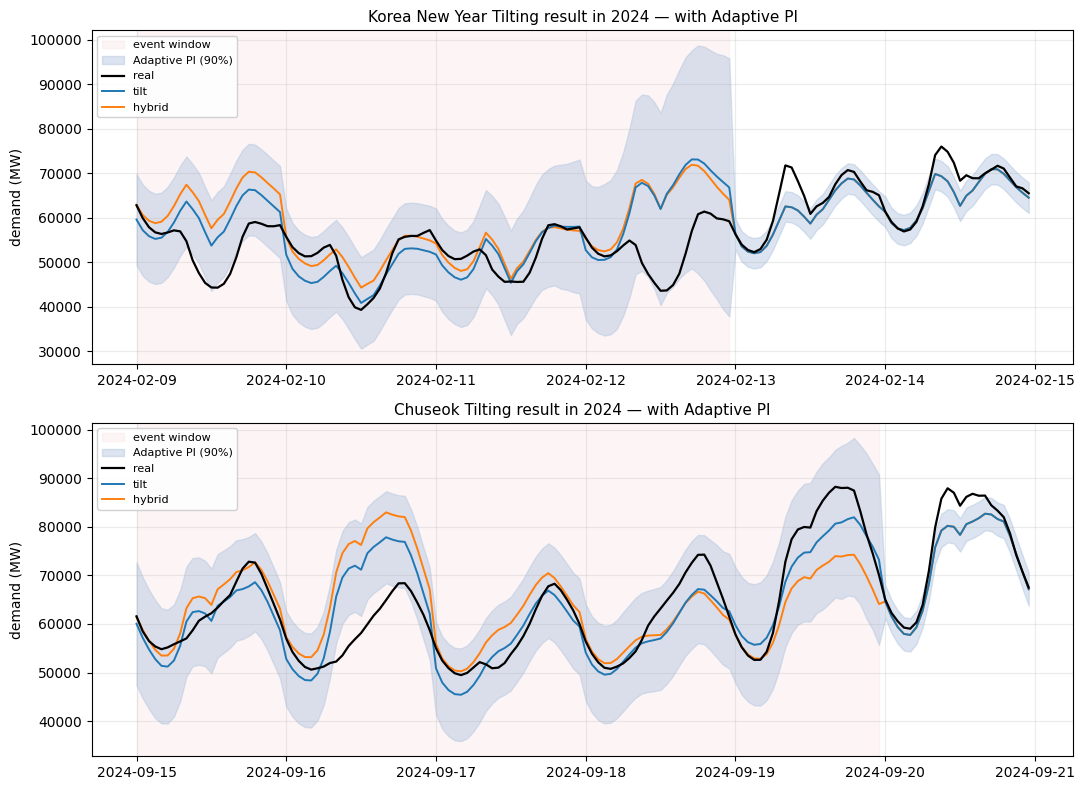

In [13]:
def _plot_holiday_window(ax, sub, title):
    event_mask = sub["e_tilt"] != 0
    if event_mask.any():
        e_start = sub.index[event_mask][0]
        e_end   = sub.index[event_mask][-1]
        ax.axvspan(e_start, e_end, color="lightcoral", alpha=0.08,
                   zorder=0, label="event window")
    ax.fill_between(sub.index, sub["lower_90_h2"], sub["upper_90_h2"],
                    color="lightsteelblue", alpha=0.45,
                    label="Adaptive PI (90%)", zorder=1)
    ax.plot(sub.index, sub["y"],            color="black",      lw=1.6, label="real",   zorder=4)
    ax.plot(sub.index, sub["tilted_pred"],  color="tab:blue",   lw=1.4, label="tilt",   zorder=3)
    ax.plot(sub.index, sub["baseline_pred"], color="tab:orange", lw=1.4, label="hybrid", zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("demand (MW)")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

fig, axes = plt.subplots(2, 1, figsize=(11, 8))
_plot_holiday_window(axes[0], preds.loc["2024-02-09":"2024-02-14"],
                     "Korea New Year Tilting result in 2024 — with Adaptive PI")
_plot_holiday_window(axes[1], preds.loc["2024-09-15":"2024-09-20"],
                     "Chuseok Tilting result in 2024 — with Adaptive PI")
plt.tight_layout()
# fig.savefig("hqt_2024_holidays.png", dpi=200, bbox_inches="tight")
plt.show()


## 13. 최종 요약

In [14]:
print("="*70)
print("  HQT 검증 결과 — 종합 요약")
print("="*70)

print("\n[1] γ_h posterior (90% CI, MW 스케일)")
print(gamma_summary.to_string(index=False))

print("\n[2] Point Accuracy — Full Test")
print(full_tbl.to_string(index=False, float_format=lambda x: f"{x:,.5f}"))

print(f"\n[3] Point Accuracy — Event Window Only (n={len(event_test_idx)})")
print(ev_tbl.to_string(index=False, float_format=lambda x: f"{x:,.5f}"))

print(f"\n[4] 90% PI Calibration")
print(pi_tbl.to_string(index=False, float_format=lambda x: f"{x:>10.2f}"))

print("\n" + "="*70)
print("  핵심 메시지")
print("="*70)
print("• γ_h 두 유형 모두 90% CI 가 0 미포함 → 통계적 유의")
print("• Event Window MAPE: H0 → H2 약 −16% (의미 있는 개선)")
print("• Event Window PICP@90%: baseline ~50% → HQT ~94% (목표 정렬)")
print("• Full Test 에서도 H2 가 모든 점예측 지표에서 최우수")


  HQT 검증 결과 — 종합 요약

[1] γ_h posterior (90% CI, MW 스케일)
   type  median (MW)  5% (MW)  95% (MW) 0 미포함?
Chuseok       -13396   -16883     -9866      ✓
Seollal        -3754    -7405       -63      ✓

[2] Point Accuracy — Full Test
            model             MSE      R²    MAPE        RMSE
      H0 baseline 9,486,481.82716 0.91227 0.03137 3,080.01328
     H1 type-mean 9,245,953.92230 0.91450 0.03117 3,040.71602
H2 HQT (proposed) 8,705,082.19253 0.91950 0.03082 2,950.43763

[3] Point Accuracy — Event Window Only (n=240)
            model              MSE      R²    MAPE        RMSE
      H0 baseline 66,766,952.17100 0.29133 0.10118 8,171.10471
     H1 type-mean 59,599,220.60618 0.36741 0.09508 7,720.05315
H2 HQT (proposed) 43,481,243.05907 0.53848 0.08468 6,594.03087

[4] 90% PI Calibration
  set    model   PICP@90%  MPIW (MW)       CRPS
 Full baseline      83.12    6828.60    1546.65
 Full      HQT      84.68    7416.67    1496.21
Event baseline      46.67    6828.60    5016.06
Event  